# Self-intersection shock zooms

Locate the outer shock in a wide-field projection, then make density, pressure, temperature, and dissipation zooms.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import re

import numpy as np
import unyt as u
from scipy.ndimage import gaussian_filter, maximum_filter

import dev  # plotting style; import before pyplot
import matplotlib.pyplot as plt

import richio
from dev.datapaths import DATAPATHS, SNAPSHOT_TFB
from richio.plots import scalar_map

## Snapshot selection

In [2]:
TDE = {
    "1e4": dev.TDEBasics(
        Mbh=1e4 * u.Msun, Mstar=0.5 * u.Msun, Rstar=0.47 * u.Rsun, beta=1
    ),
    "1e5": dev.TDEBasics(
        Mbh=1e5 * u.Msun, Mstar=0.5 * u.Msun, Rstar=0.47 * u.Rsun, beta=1
    ),
    "1e6": dev.TDEBasics(
        Mbh=1e6 * u.Msun, Mstar=1.0 * u.Msun, Rstar=1.0 * u.Rsun, beta=1
    ),
}
REQUESTED_TFBS = {
    "1e4": [0.5, 1.0, 1.5, 2.0],
    "1e5": [0.3, 0.5],
    "1e6": [1.0, 1.2, 1.4, 1.5],
}
DROP_INDICES = {"1e4": {0, 3}, "1e5": {0}, "1e6": {2, 3}}

SELECTED = {}
for run, requested in REQUESTED_TFBS.items():
    cases = [(*SNAPSHOT_TFB(run, tfb), False) for tfb in requested]
    snapnums, paths = DATAPATHS(run)
    cases.append((snapnums[-1], paths[-1], True))
    SELECTED[run] = [case for i, case in enumerate(cases) if i not in DROP_INDICES[run]]

for run, cases in SELECTED.items():
    print(run, [(snapnum, path.name, is_last) for snapnum, path, is_last in cases])

1e4 [(77, 'snap_full_77.h5', False), (108, 'snap_full_108.h5', False), (151, 'snap_full_151.h5', True)]
1e5 [(142, 'snap_full_142.h5', False), (161, 'snap_full_161.h5', True)]
1e6 [(850, 'snap_850.h5', False), (905, 'snap_905.h5', False), (1006, 'snap_1006.h5', True)]


In [3]:
def needs_reference_frame(run, path):
    path = Path(path)
    if run == "1e6":
        return path.parent.name == "TEMPTDE"
    return re.fullmatch(r"snap_\d+\.h5", path.name) is not None


def plotting_coordinates(snap, run, path):
    x, y, z = snap.X, snap.Y, snap.Z
    if needs_reference_frame(run, path):
        tde = TDE[run]
        offset = dev.reference_frame_offset(
            t=snap.time,
            Mbh=tde.Mbh,
            Mstar=tde.Mstar,
            Rstar=tde.Rstar,
            beta=1,
        )
        x, y = x + offset[0], y + offset[1]
    return x, y, z


_SNAP_CACHE = {}


def load_case(run, case_index):
    snapnum, path, is_last = SELECTED[run][case_index]
    key = str(path)
    if key not in _SNAP_CACHE:
        _SNAP_CACHE[key] = richio.load(path)
    snap = _SNAP_CACHE[key]
    x, y, z = plotting_coordinates(snap, run, path)
    time_tfb = float(np.asarray((snap.time / TDE[run].t_fb).to_value()).squeeze())
    return {
        "run": run,
        "snapnum": snapnum,
        "path": Path(path),
        "is_last": is_last,
        "snap": snap,
        "x": x,
        "y": y,
        "z": z,
        "time_tfb": time_tfb,
        "tde": TDE[run],
    }

## Wide-field inspection

In [4]:
MOVIE_WINDOW = (-1.5, 0.5, -0.7, 0.7)  # xmin, xmax, ymin, ymax in r_amin
MOVIE_WINDOW_OVERRIDES = {"1e4": (-2.0, 0.5, -0.875, 0.875)}
INNER_EXCLUSION_FRACTION_RAMIN = 0.2
OVERVIEW_BINS = 384


def wide_bounds_rp(case):
    window = MOVIE_WINDOW_OVERRIDES.get(case["run"], MOVIE_WINDOW)
    scale = float((case["tde"].r_a / case["tde"].r_p).to_value())
    return tuple(scale * np.asarray(window))


def finite_log_limits(values, span=6):
    logged = np.log10(values[np.isfinite(values) & (values > 0)])
    if not logged.size:
        raise ValueError("No finite positive pixels")
    vmax = np.ceil(2 * np.percentile(logged, 99.5)) / 2
    vmin = max(np.floor(2 * np.percentile(logged, 0.5)) / 2, vmax - span)
    return vmin, vmax


def ranked_outer_peaks(dissipation_column, xcenters, ycenters, exclusion_rp, count=8):
    smoothed = gaussian_filter(np.nan_to_num(dissipation_column), sigma=1.5)
    xx, yy = np.meshgrid(xcenters, ycenters, indexing="ij")
    allowed = xx**2 + yy**2 >= exclusion_rp**2
    local_max = smoothed == maximum_filter(smoothed, size=13)
    candidates = np.argwhere(local_max & allowed & (smoothed > 0))
    order = np.argsort(smoothed[tuple(candidates.T)])[::-1]
    peaks = []
    for i, j in candidates[order[:count]]:
        peaks.append((float(xcenters[i]), float(ycenters[j]), float(smoothed[i, j])))
    return peaks


def plot_overview(
    case, bins=OVERVIEW_BINS, exclusion_fraction_ramin=INNER_EXCLUSION_FRACTION_RAMIN
):
    snap, rp = case["snap"], case["tde"].r_p
    x = np.asarray((case["x"] / rp).to_value())
    y = np.asarray((case["y"] / rp).to_value())
    xmin, xmax, ymin, ymax = wide_bounds_rp(case)
    exclusion_rp = exclusion_fraction_ramin * float((case["tde"].r_a / rp).to_value())
    xedges = np.linspace(xmin, xmax, bins + 1)
    yedges = np.linspace(ymin, ymax, bins + 1)
    in_view = (x >= xmin) & (x <= xmax) & (y >= ymin) & (y <= ymax)
    mass = np.asarray((snap.density * snap.volume).to_value("g"))
    power = np.asarray((snap.dissipation * snap.volume).to_value("erg/s"))
    mass_column, _, _ = np.histogram2d(
        x[in_view],
        y[in_view],
        bins=(xedges, yedges),
        weights=mass[in_view],
    )
    diss_column, _, _ = np.histogram2d(
        x[in_view],
        y[in_view],
        bins=(xedges, yedges),
        weights=power[in_view],
    )
    pixel_area = (
        np.outer(np.diff(xedges), np.diff(yedges)) * float(rp.to_value("cm")) ** 2
    )
    mass_column /= pixel_area
    diss_column /= pixel_area
    xcenters = 0.5 * (xedges[:-1] + xedges[1:])
    ycenters = 0.5 * (yedges[:-1] + yedges[1:])
    peaks = ranked_outer_peaks(diss_column, xcenters, ycenters, exclusion_rp)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11.5, 4.2),
        sharex=True,
        sharey=True,
        dpi=160,
        layout="constrained",
    )
    panels = (
        (mass_column, "twilight", r"$\log_{10}\Sigma\;[\mathrm{g\,cm^{-2}}]$", 6),
        (
            diss_column,
            "viridis",
            r"$\log_{10}\dot E_\mathrm{diss}/A\;[\mathrm{erg\,s^{-1}\,cm^{-2}}]$",
            2,
        ),
    )
    for ax, (values, cmap, label, span) in zip(axes, panels):
        vmin, vmax = finite_log_limits(values, span=span)
        image = ax.pcolormesh(
            xedges,
            yedges,
            np.log10(np.where(values > 0, values, np.nan)).T,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="flat",
            rasterized=True,
        )
        fig.colorbar(image, ax=ax, label=label, fraction=0.045, pad=0.025, aspect=30)
        circle = plt.Circle(
            (0, 0), exclusion_rp, fill=False, color="white", linestyle="--"
        )
        ax.add_patch(circle)
        for rank, (xp, yp, _) in enumerate(peaks):
            ax.scatter(xp, yp, s=35, facecolor="none", edgecolor="white")
            ax.text(xp, yp, f" {rank}", color="white", fontsize=8, va="bottom")
        ax.set_aspect("equal")
        ax.set_xlabel(r"$x/r_p$")
    axes[0].set_ylabel(r"$y/r_p$")
    last = "; last snapshot" if case["is_last"] else ""
    print(
        f"{case['run']}, snap {case['snapnum']}, t/t_fb={case['time_tfb']:.3f}" + last
    )
    return fig, peaks

In [5]:
RUN_CASE_INDICES = {"1e4": 0, "1e5": 0, "1e6": 0}
CANDIDATE_RANKS = {"1e4": 0, "1e5": 0, "1e6": 0}
SELF_INTERSECTION_PRESENT = {"1e4": True, "1e5": False, "1e6": True}
MANUAL_CENTERS_XY_RP = {}  # e.g. {"1e5": (-70.0, -3.0)}
REFINE_APERTURE_RP = 2.0

## Refine center

In [6]:
def weighted_median(values, weights):
    order = np.argsort(values)
    values, weights = values[order], weights[order]
    return float(values[np.searchsorted(np.cumsum(weights), 0.5 * weights.sum())])


def refine_center(case, center_xy_rp, aperture_rp=REFINE_APERTURE_RP):
    snap, rp = case["snap"], case["tde"].r_p
    xyz = [
        np.asarray((coord / rp).to_value())
        for coord in (case["x"], case["y"], case["z"])
    ]
    projected_distance = np.hypot(xyz[0] - center_xy_rp[0], xyz[1] - center_xy_rp[1])
    selected = projected_distance <= aperture_rp
    weights = np.asarray((snap.dissipation * snap.volume).to_value("erg/s"))
    selected &= np.isfinite(weights) & (weights > 0)
    if not np.any(selected):
        raise ValueError(
            "No dissipating cells in the refinement aperture; enlarge REFINE_APERTURE_RP"
        )
    return tuple(weighted_median(axis[selected], weights[selected]) for axis in xyz)


def choose_center(case, peaks):
    run = case["run"]
    center_xy_rp = MANUAL_CENTERS_XY_RP.get(run, peaks[CANDIDATE_RANKS[run]][:2])
    center_rp = refine_center(case, center_xy_rp)
    location_label = (
        "self-intersection center"
        if SELF_INTERSECTION_PRESENT[run]
        else "diagnostic center; no self-intersection yet"
    )
    print(
        f"{run} {location_label} (x, y, z) / r_p:",
        tuple(round(value, 3) for value in center_rp),
    )
    return center_rp

## Four-field zoom

In [7]:
FIELD_STYLE = (
    ("density", "Density", "twilight"),
    ("pressure", "Gas pressure", "rainbow"),
    ("temperature", "Temperature", "inferno"),
    ("dissipation", "Dissipation", "viridis"),
)
AXES = {"xy": ("x", "y", "z"), "yz": ("y", "z", "x"), "zx": ("z", "x", "y")}
VELOCITY_FIELDS = {"xy": ("vx", "vy"), "yz": ("vy", "vz"), "zx": ("vz", "vx")}
COLORBAR_LABELS = {
    "slice": {
        "density": r"$\log_{10}(\rho/[\mathrm{g\,cm^{-3}}])$",
        "pressure": r"$\log_{10}(P/[\mathrm{dyn\,cm^{-2}}])$",
        "temperature": r"$\log_{10}(T/\mathrm{K})$",
        "dissipation": r"$\log_{10}(\dot E_{\rm diss}/[\mathrm{erg\,s^{-1}\,cm^{-3}}])$",
    },
    "projection": {
        "density": r"$\log_{10}(\Sigma/[\mathrm{g\,cm^{-2}}])$",
        "pressure": r"$\log_{10}(\langle P\rangle_\rho/[\mathrm{dyn\,cm^{-2}}])$",
        "temperature": r"$\log_{10}(\langle T\rangle_\rho/\mathrm{K})$",
        "dissipation": r"$\log_{10}[(\dot E_{\rm diss}/A)/[\mathrm{erg\,s^{-1}\,cm^{-2}}]]$",
    },
}


def physical_box(center_rp, half_width_rp, rp):
    center = np.asarray(center_rp) * rp
    half = np.asarray(half_width_rp) * rp
    return u.unyt_array([*(center - half), *(center + half)])


def cell_flow_diagnostics(snap):
    density = snap.density.in_cgs()
    pressure = snap.pressure.in_cgs()
    specific_internal_energy = snap.internal_energy.in_cgs()
    gamma_effective = 1 + pressure / (density * specific_internal_energy)
    sound_speed = np.sqrt(gamma_effective * pressure / density).in_units("km/s")
    speed = np.sqrt(snap.vx**2 + snap.vy**2 + snap.vz**2).in_units("km/s")
    return {
        "mach_proxy": (speed / sound_speed).in_units("dimensionless"),
        "entropy": snap.entropy.in_cgs(),
        "speed": speed,
        "sound_speed": sound_speed,
        "_gamma_effective": gamma_effective.in_units("dimensionless"),
    }


def slice_fields(case, center_rp, half_width_rp, plane, resolution, workers):
    snap, rp = case["snap"], case["tde"].r_p
    box = physical_box(center_rp, half_width_rp, rp)
    normal_index = {"xy": 2, "yz": 0, "zx": 1}[plane]
    indices, first, second = snap.to_2dgrid(
        res=resolution,
        X=case["x"],
        Y=case["y"],
        Z=case["z"],
        plane=plane,
        slice_coord=center_rp[normal_index] * rp,
        box_size=box,
        volume_selection=True,
        workers=workers,
    )
    fields = {name: getattr(snap, name)[indices].in_cgs() for name, *_ in FIELD_STYLE}
    first_velocity, second_velocity = VELOCITY_FIELDS[plane]
    fields["_velocity_first"] = getattr(snap, first_velocity)[indices].in_units("km/s")
    fields["_velocity_second"] = getattr(snap, second_velocity)[indices].in_units(
        "km/s"
    )
    diagnostics = cell_flow_diagnostics(snap)
    fields.update({name: values[indices] for name, values in diagnostics.items()})
    return fields, first / rp, second / rp


def projection_fields(case, center_rp, half_width_rp, plane, resolution, workers):
    snap, rp = case["snap"], case["tde"].r_p
    box = physical_box(center_rp, half_width_rp, rp)
    indices, first, second, normal = snap.to_3dgrid(
        res=resolution,
        X=case["x"],
        Y=case["y"],
        Z=case["z"],
        plane=plane,
        box_size=box,
        workers=workers,
    )
    core = indices[:-1, :-1, :-1]
    depth = (normal[1:] - normal[:-1]).reshape(1, 1, -1)
    rho = snap.density[core].in_cgs()
    density_column = np.sum(rho * depth, axis=-1)
    pressure = (
        np.sum(rho * snap.pressure[core].in_cgs() * depth, axis=-1) / density_column
    )
    temperature = (
        np.sum(rho * snap.temperature[core].in_cgs() * depth, axis=-1) / density_column
    )
    dissipation_column = np.sum(snap.dissipation[core].in_cgs() * depth, axis=-1)
    first_velocity, second_velocity = VELOCITY_FIELDS[plane]
    velocity_first = (
        np.sum(
            rho * getattr(snap, first_velocity)[core].in_units("km/s") * depth, axis=-1
        )
        / density_column
    )
    velocity_second = (
        np.sum(
            rho * getattr(snap, second_velocity)[core].in_units("km/s") * depth, axis=-1
        )
        / density_column
    )
    diagnostics = {
        name: np.sum(rho * values[core] * depth, axis=-1) / density_column
        for name, values in cell_flow_diagnostics(snap).items()
    }
    fields = {
        "density": density_column,
        "pressure": pressure,
        "temperature": temperature,
        "dissipation": dissipation_column,
        "_velocity_first": velocity_first,
        "_velocity_second": velocity_second,
        **diagnostics,
    }
    return fields, first[:-1] / rp, second[:-1] / rp


def plot_zoom(
    case,
    center_rp,
    kind="slice",
    plane="xy",
    half_width_rp=(3, 3, 1),
    resolution=768,
    projection_depth_resolution=96,
    workers=8,
    figure_size=(13.5, 6.5),
):
    if kind == "slice":
        fields, first, second = slice_fields(
            case,
            center_rp,
            half_width_rp,
            plane,
            resolution,
            workers,
        )
    elif kind == "projection":
        if np.isscalar(resolution):
            projection_resolution = (
                resolution,
                resolution,
                projection_depth_resolution,
            )
        else:
            projection_resolution = (*resolution, projection_depth_resolution)
        fields, first, second = projection_fields(
            case,
            center_rp,
            half_width_rp,
            plane,
            projection_resolution,
            workers,
        )
    else:
        raise ValueError("kind must be 'slice' or 'projection'")

    fig, axes = plt.subplots(
        2,
        2,
        figsize=figure_size,
        sharex=True,
        sharey=True,
        dpi=160,
        layout="constrained",
    )
    for ax, (name, title, cmap) in zip(axes.flat, FIELD_STYLE):
        values = fields[name].copy()
        values[~np.isfinite(values) | (values <= 0)] = np.nan
        color_limits = {}
        if name == "dissipation":
            vmax = float(np.nanmax(np.log10(np.asarray(values))))
            color_limits = {"vmin": vmax - 2, "vmax": vmax}
        scalar_map(
            values,
            first,
            second,
            ax=ax,
            cmap=cmap,
            colorbar_label=COLORBAR_LABELS[kind][name],
            colorbar_pad=0.02,
            **color_limits,
        )
        ax.set_title(title)

    axes.flat[0].streamplot(
        np.asarray(first),
        np.asarray(second),
        np.asarray(fields["_velocity_first"]).T,
        np.asarray(fields["_velocity_second"]).T,
        color="white",
        density=1.25,
        linewidth=0.65,
        arrowsize=0.8,
        zorder=5,
    )
    first_name, second_name, _ = AXES[plane]
    for ax in axes[-1]:
        ax.set_xlabel(rf"${first_name}/r_p$")
    for ax in axes[:, 0]:
        ax.set_ylabel(rf"${second_name}/r_p$")
    print(
        f"{case['run']}, snap {case['snapnum']}, {kind} in {plane}; "
        f"t/t_fb={case['time_tfb']:.3f}"
    )
    fields["_first_coordinate"] = first
    fields["_second_coordinate"] = second
    return fig, axes, fields


DIAGNOSTIC_STYLE = (
    ("mach_proxy", r"$|v|/c_s$", "magma", r"$\log_{10}(|v|/c_s)$"),
    (
        "entropy",
        "Specific entropy",
        "plasma",
        r"$\log_{10}(s/[\mathrm{erg\,K^{-1}\,g^{-1}}])$",
    ),
    ("speed", r"$|v|$", "viridis", r"$\log_{10}(|v|/[\mathrm{km\,s^{-1}}])$"),
    ("sound_speed", r"$c_s$", "cividis", r"$\log_{10}(c_s/[\mathrm{km\,s^{-1}}])$"),
)


def plot_flow_diagnostics(fields, first, second, plane, figure_size=(13.5, 6.5)):
    fig, axes = plt.subplots(
        2,
        2,
        figsize=figure_size,
        sharex=True,
        sharey=True,
        dpi=160,
        layout="constrained",
    )
    for ax, (name, title, cmap, colorbar_label) in zip(axes.flat, DIAGNOSTIC_STYLE):
        values = fields[name].copy()
        values[~np.isfinite(values) | (values <= 0)] = np.nan
        scalar_map(
            values,
            first,
            second,
            ax=ax,
            cmap=cmap,
            colorbar_label=colorbar_label,
            colorbar_pad=0.02,
        )
        ax.set_title(title)

    first_name, second_name, _ = AXES[plane]
    for ax in axes[-1]:
        ax.set_xlabel(rf"${first_name}/r_p$")
    for ax in axes[:, 0]:
        ax.set_ylabel(rf"${second_name}/r_p$")

    gamma_values = np.asarray(fields["_gamma_effective"])
    gamma_values = gamma_values[np.isfinite(gamma_values) & (gamma_values > 0)]
    print(
        "c_s^2 = gamma_eff P/rho, gamma_eff = 1 + P/(rho u); "
        f"gamma_eff 1--99 percentile = {np.percentile(gamma_values, 1):.3f}--"
        f"{np.percentile(gamma_values, 99):.3f}"
    )
    return fig, axes

1e4, snap 77, t/t_fb=1.006


1e4 self-intersection center (x, y, z) / r_p: (-10.583, 4.015, -0.003)


1e4, snap 77, slice in xy; t/t_fb=1.006


c_s^2 = gamma_eff P/rho, gamma_eff = 1 + P/(rho u); gamma_eff 1--99 percentile = 1.177--1.539


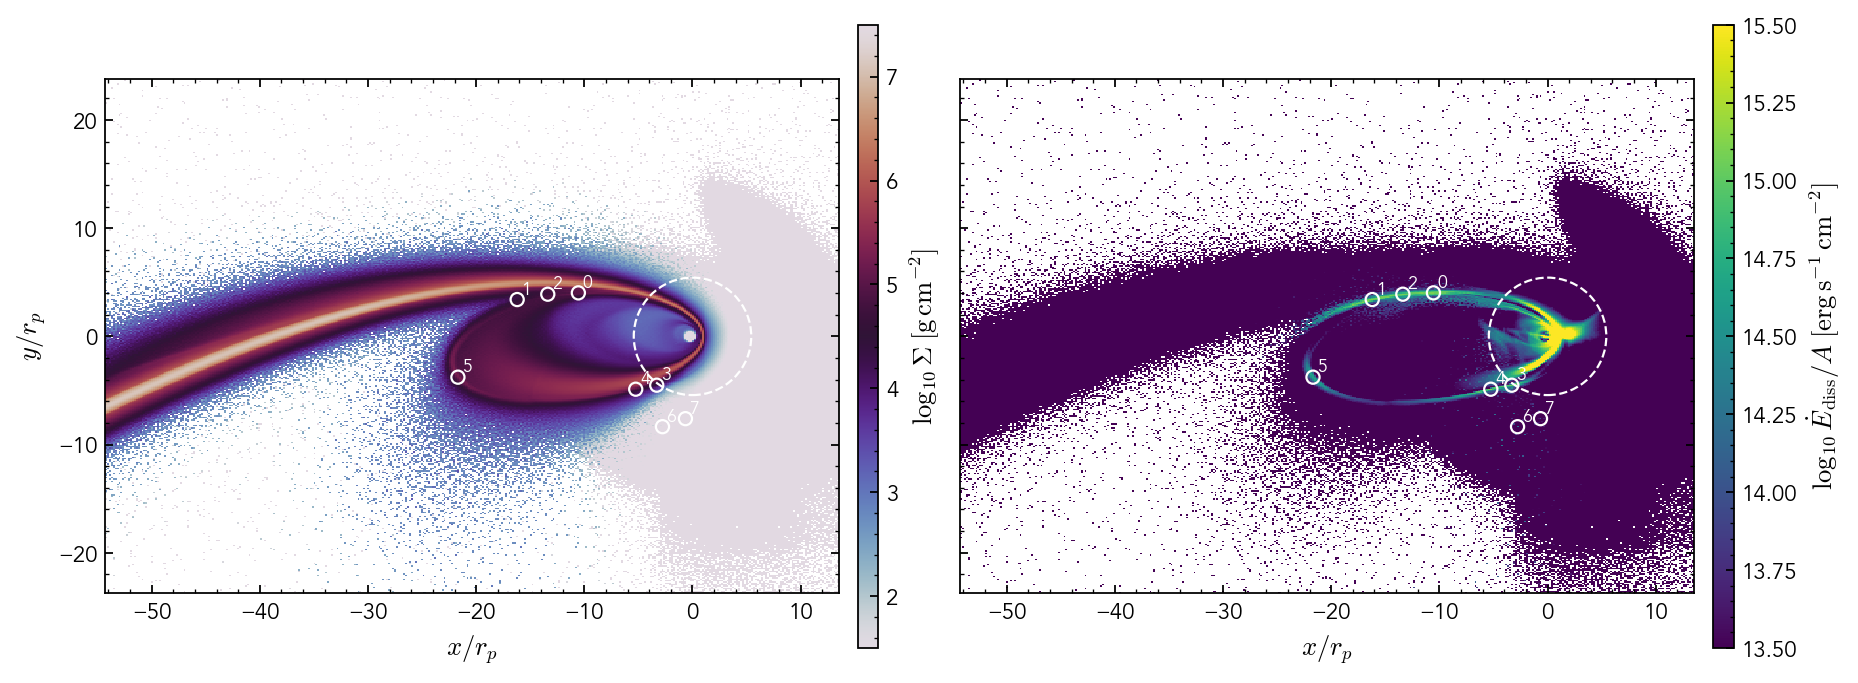

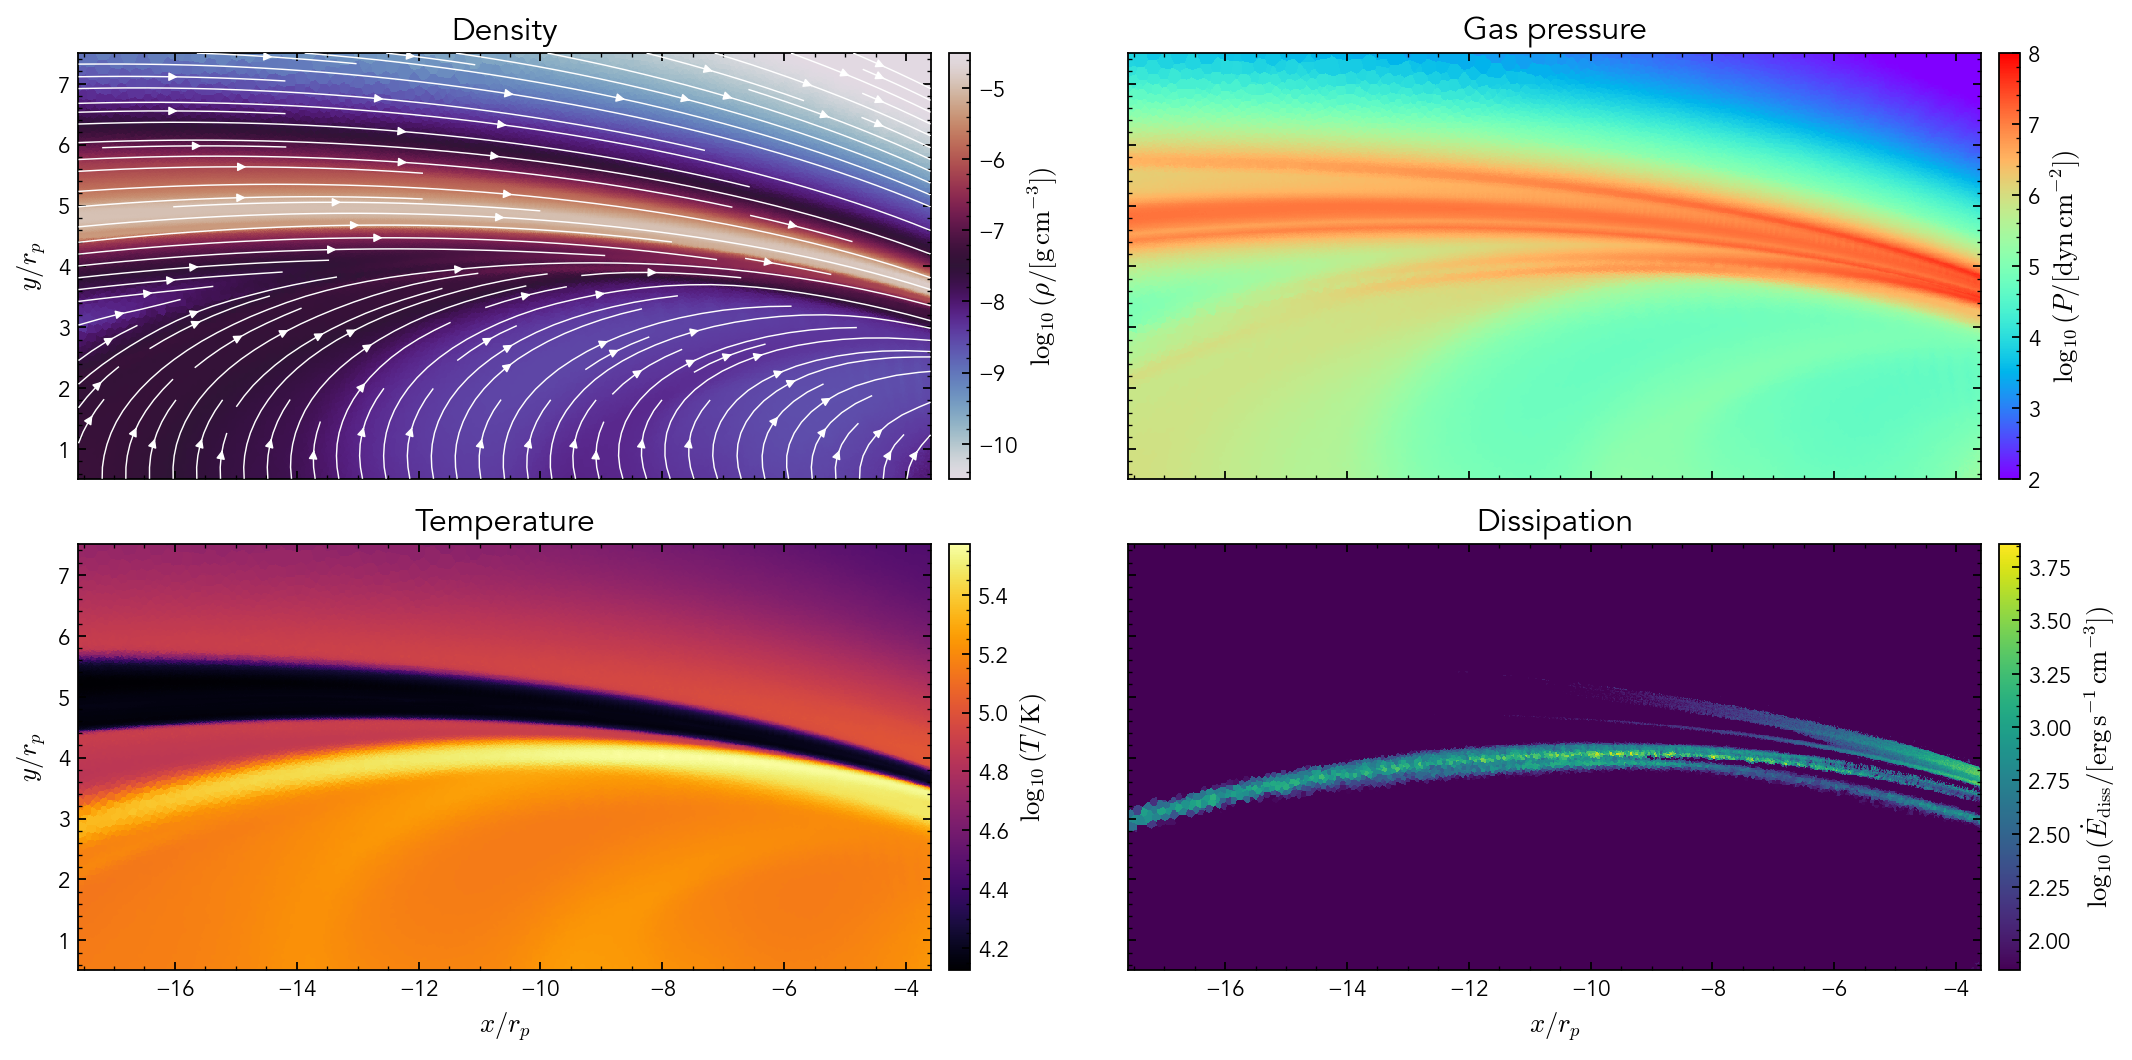

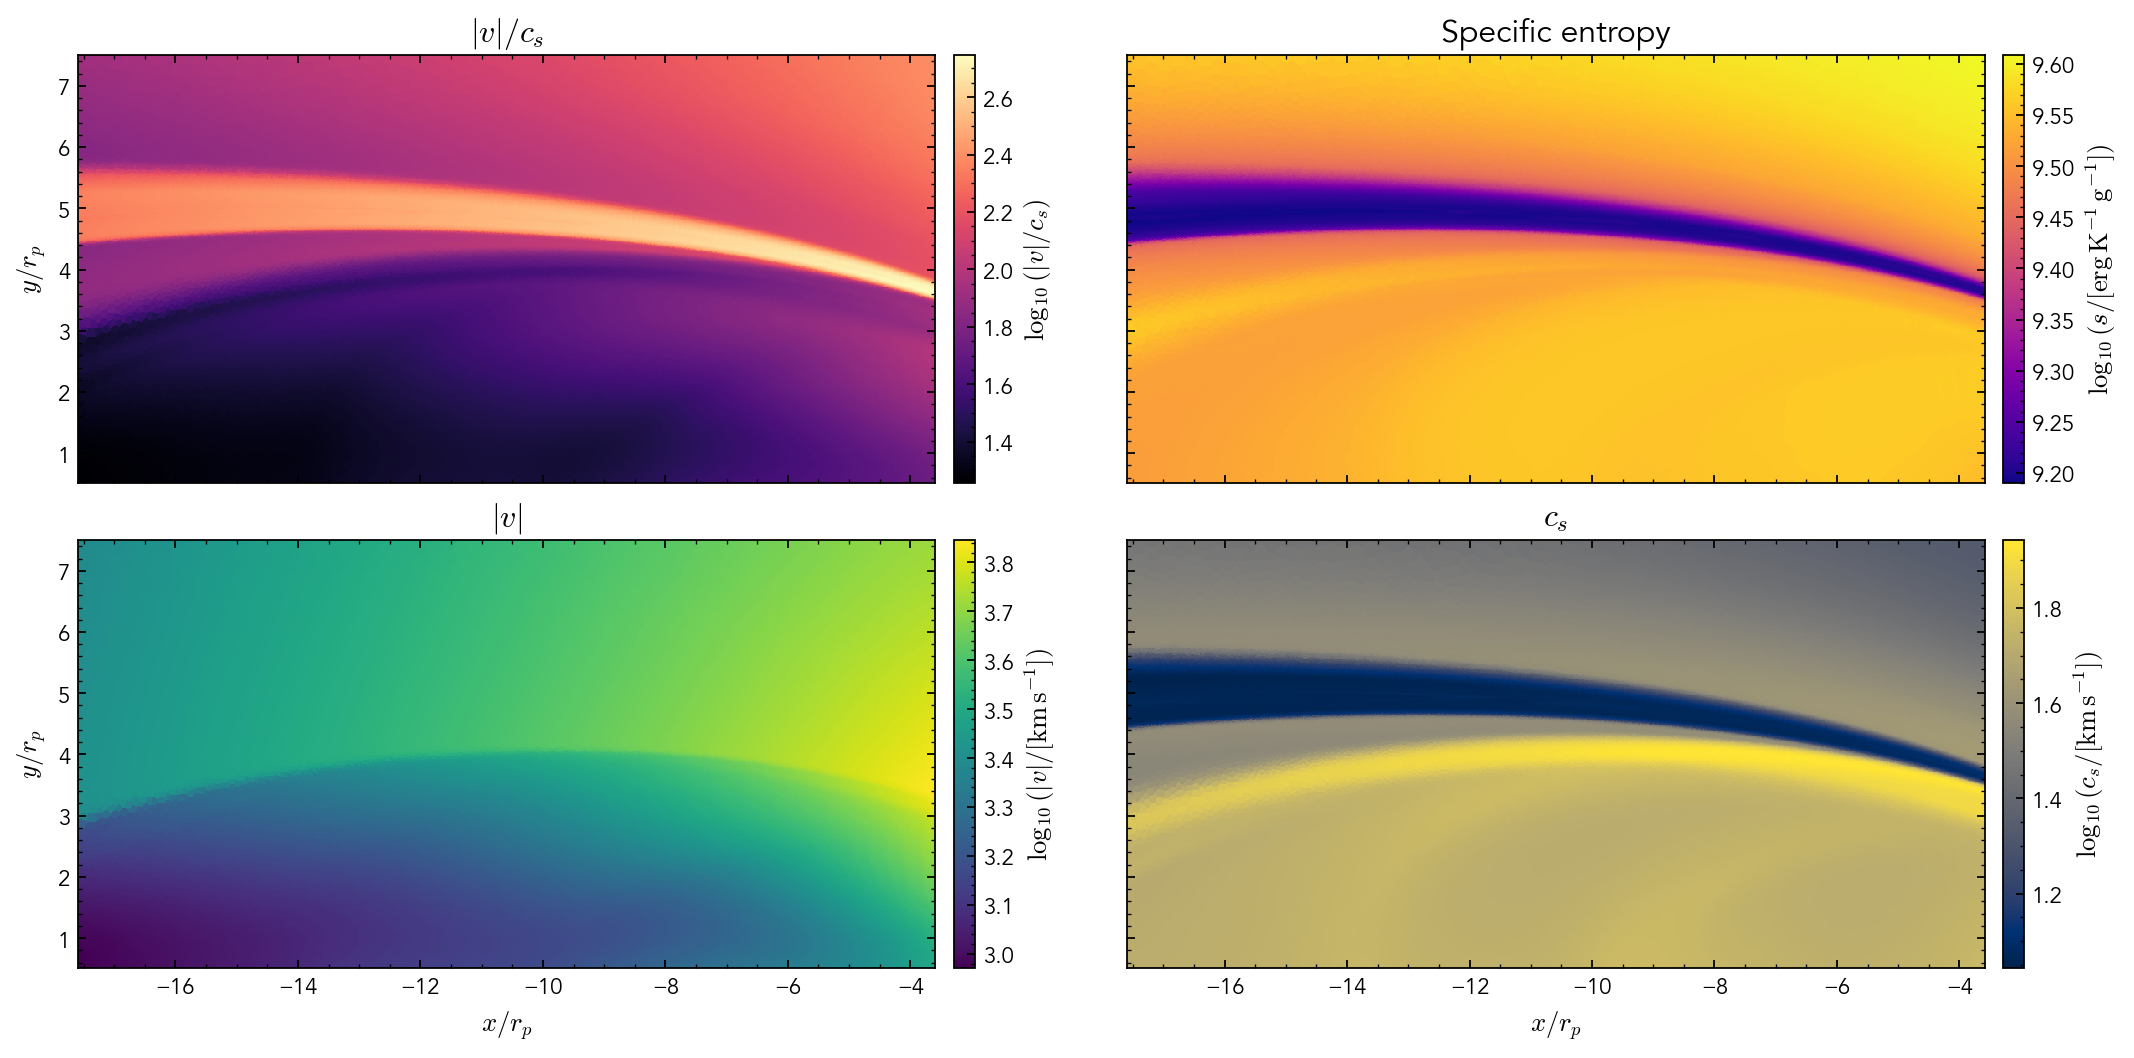

1e5, snap 142, t/t_fb=0.501


1e5 diagnostic center; no self-intersection yet (x, y, z) / r_p: (-70.102, -3.145, -0.0)


1e5, snap 142, slice in xy; t/t_fb=0.501


c_s^2 = gamma_eff P/rho, gamma_eff = 1 + P/(rho u); gamma_eff 1--99 percentile = 1.059--1.309


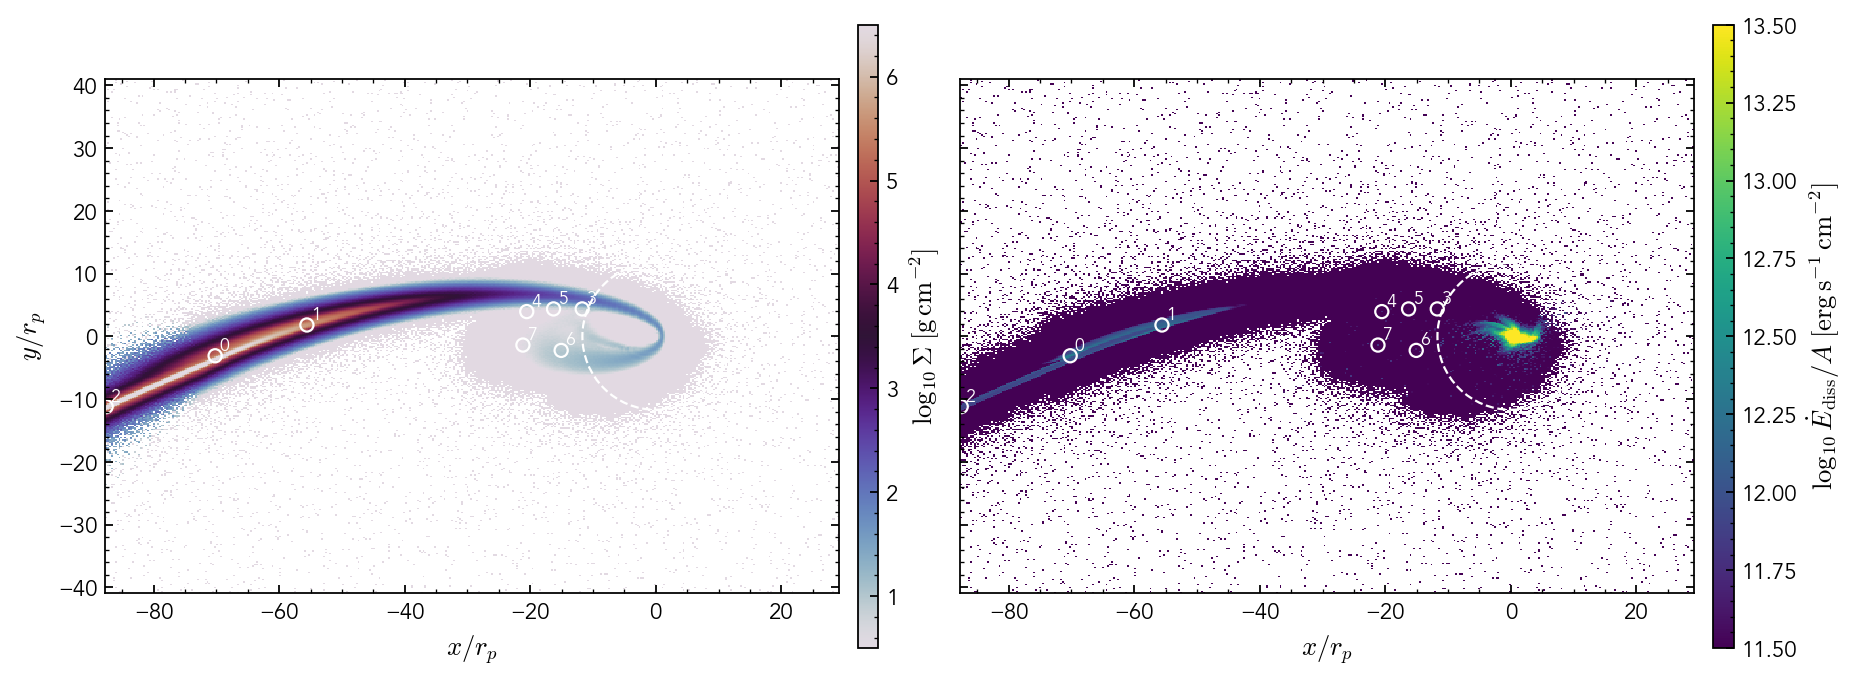

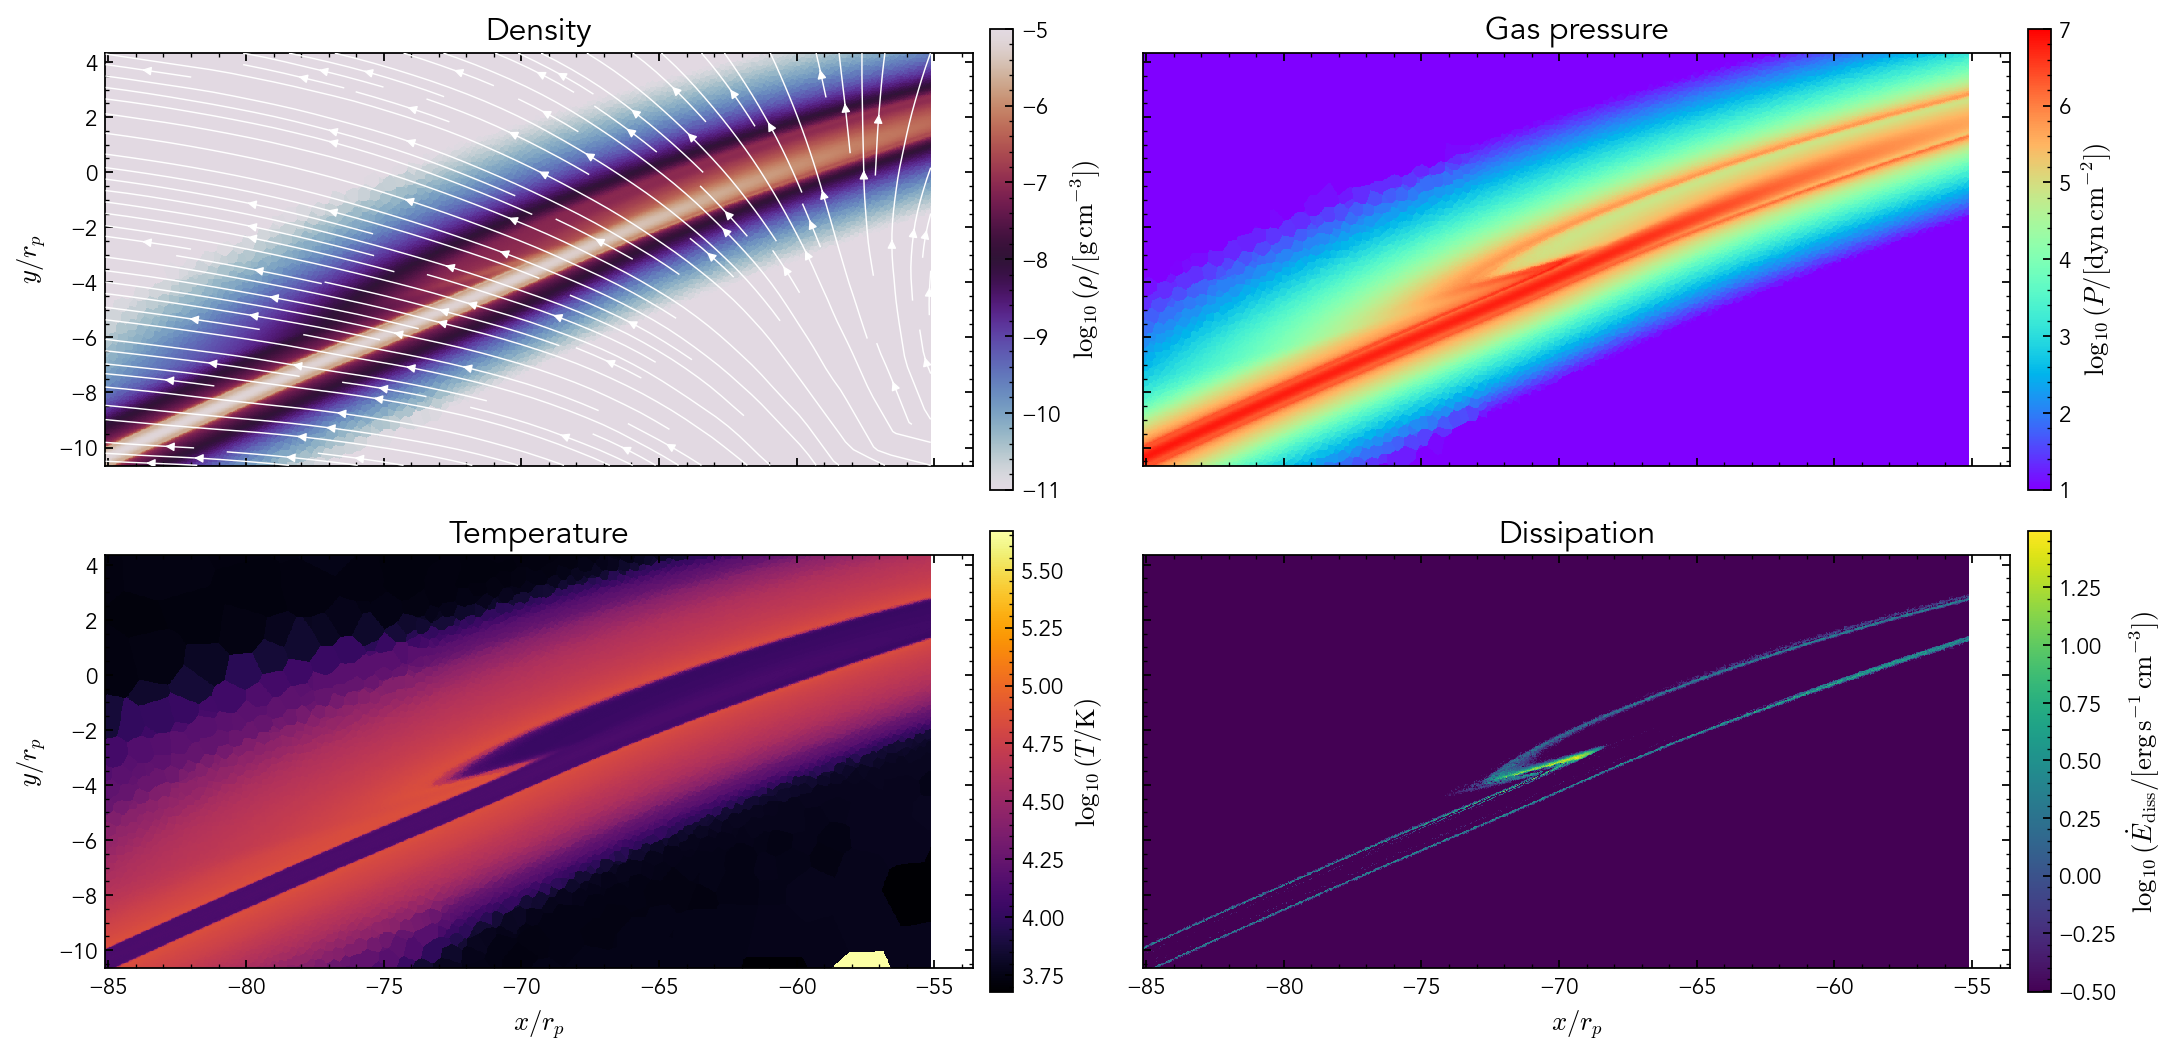

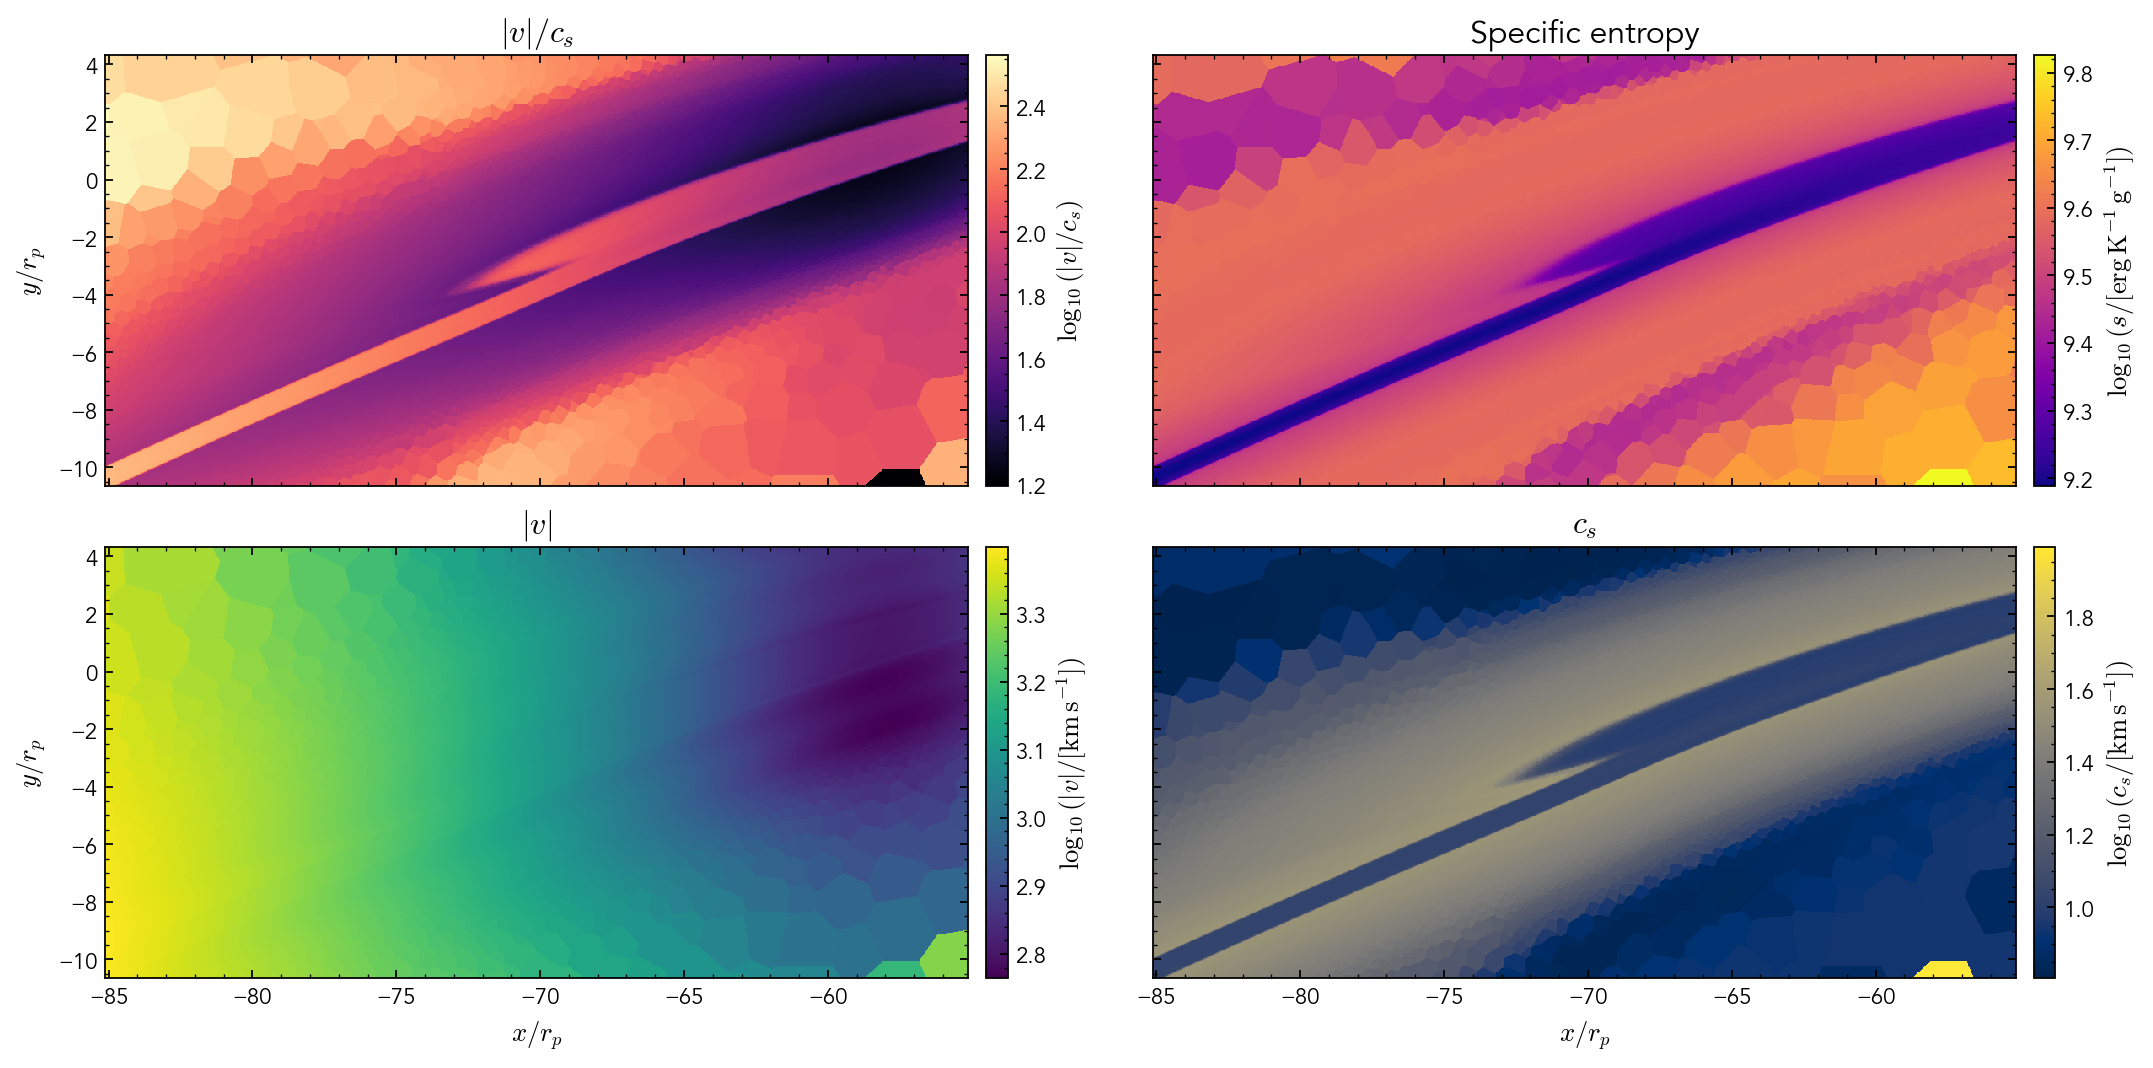

1e6, snap 850, t/t_fb=1.008


1e6 self-intersection center (x, y, z) / r_p: (-94.545, 12.495, -0.015)


1e6, snap 850, slice in xy; t/t_fb=1.008


c_s^2 = gamma_eff P/rho, gamma_eff = 1 + P/(rho u); gamma_eff 1--99 percentile = 1.102--1.295


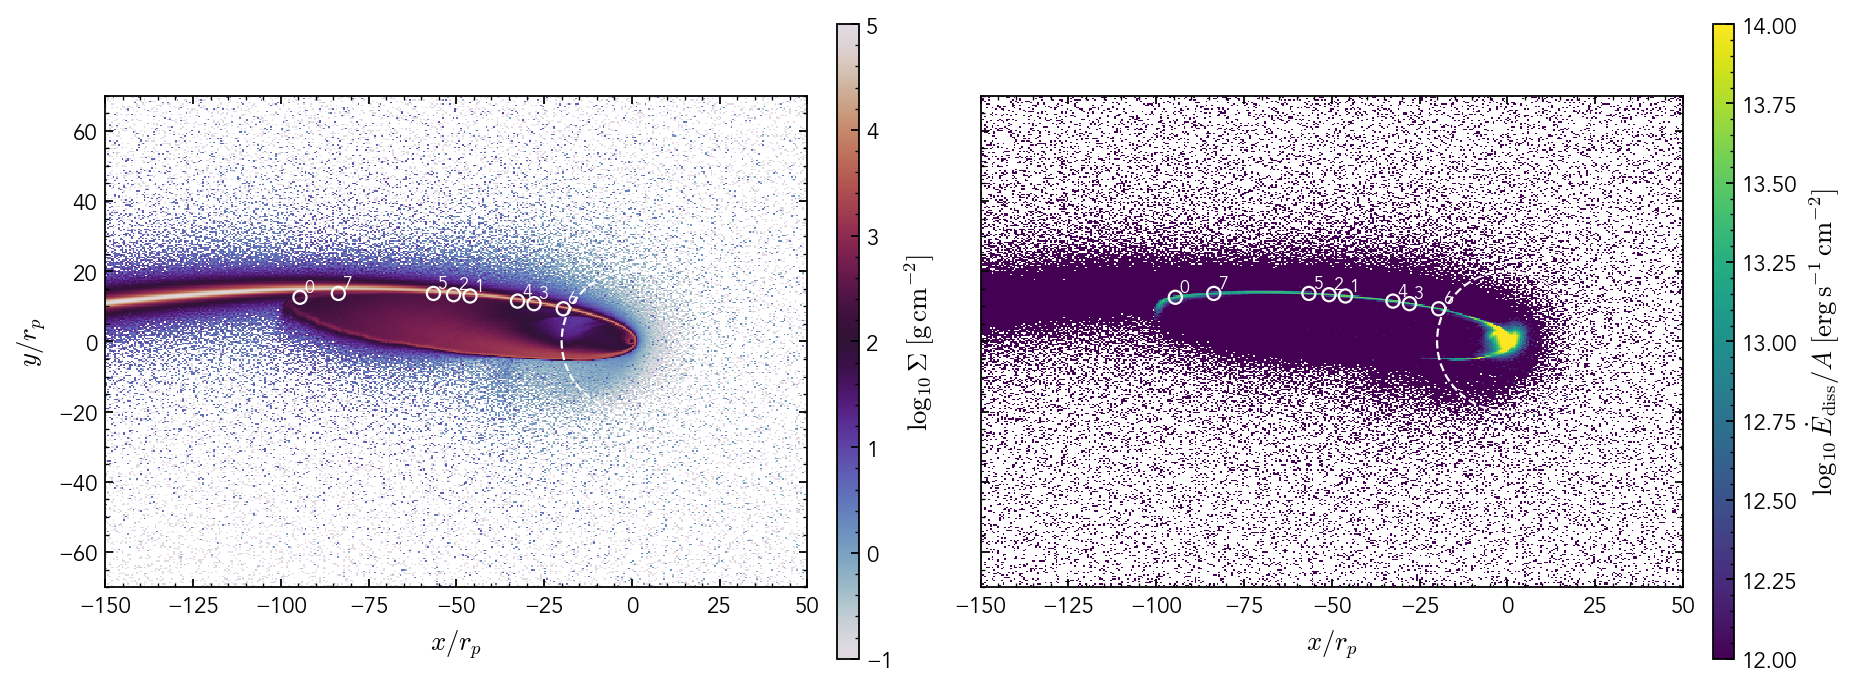

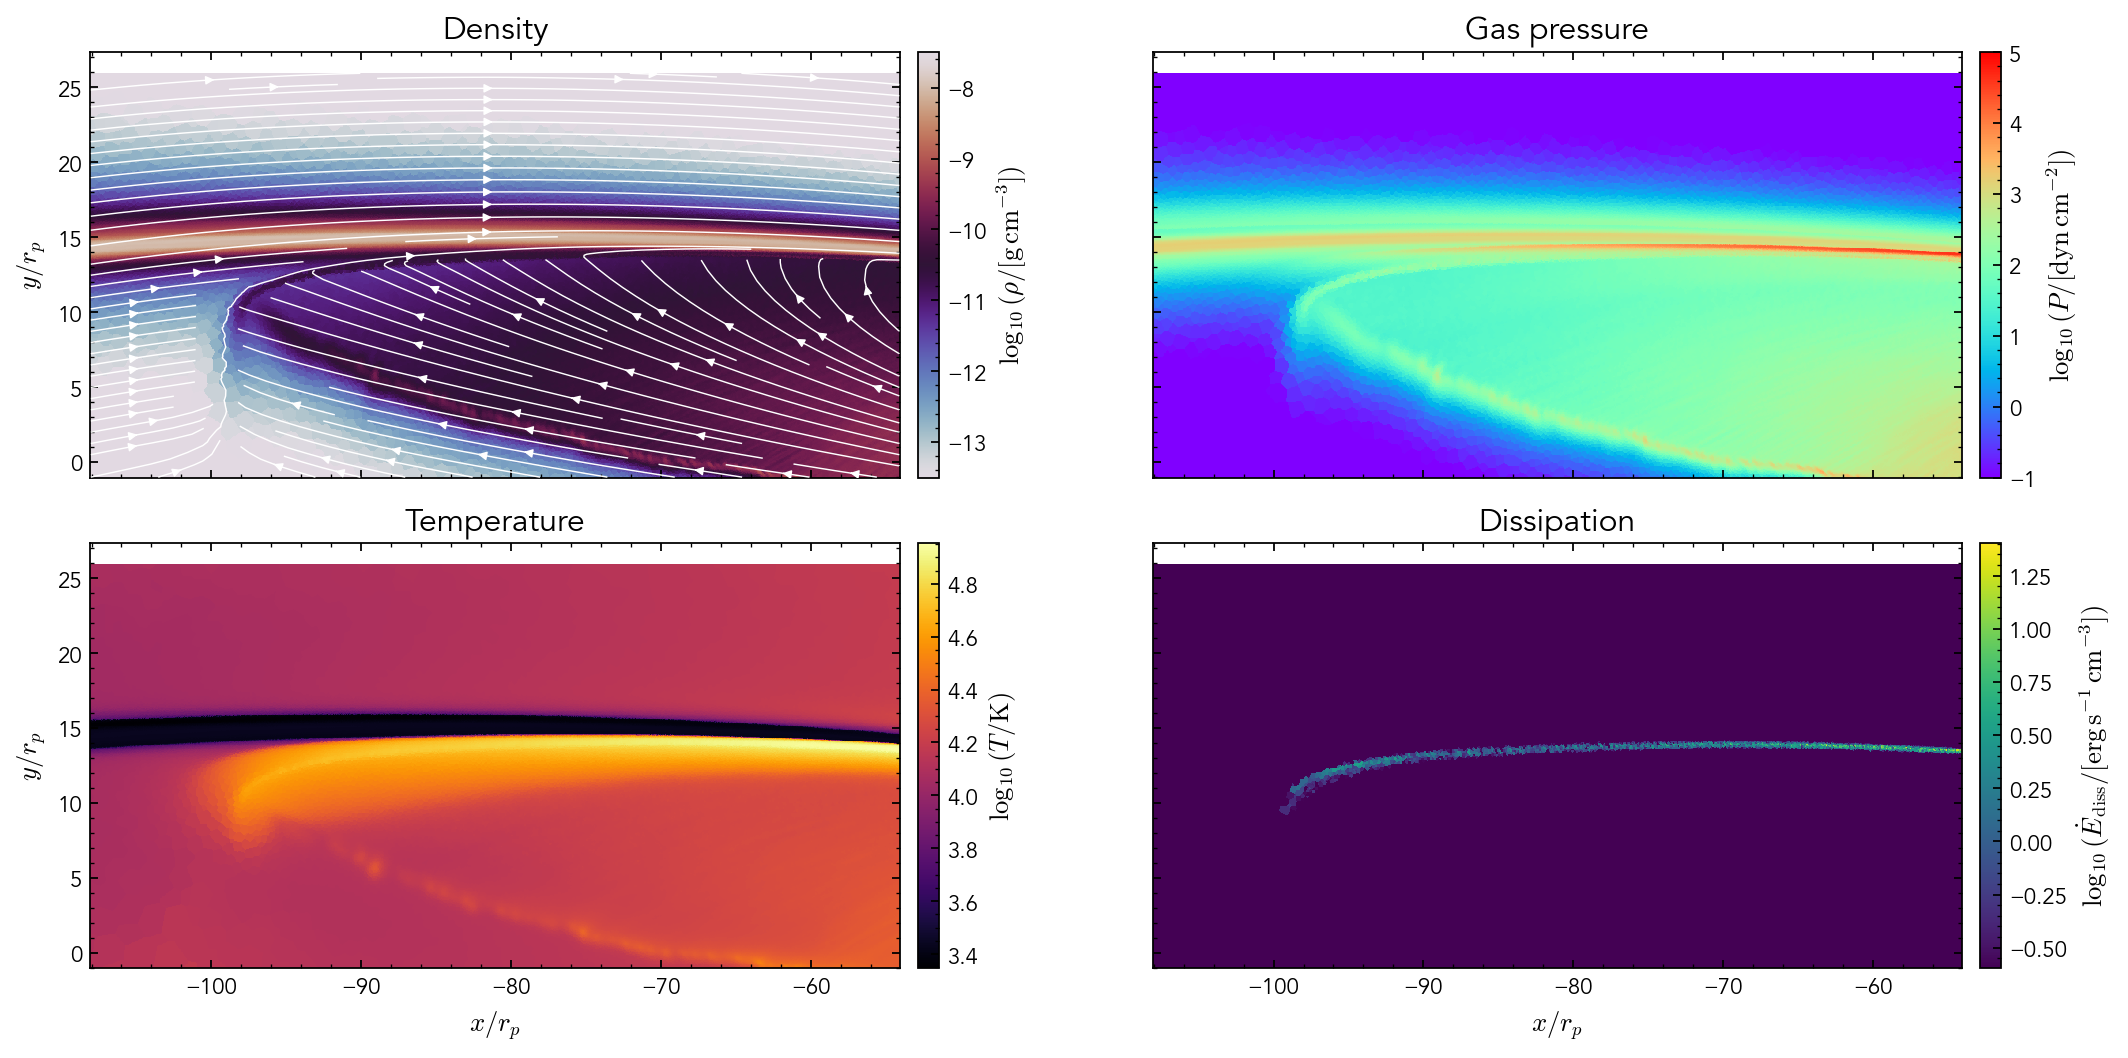

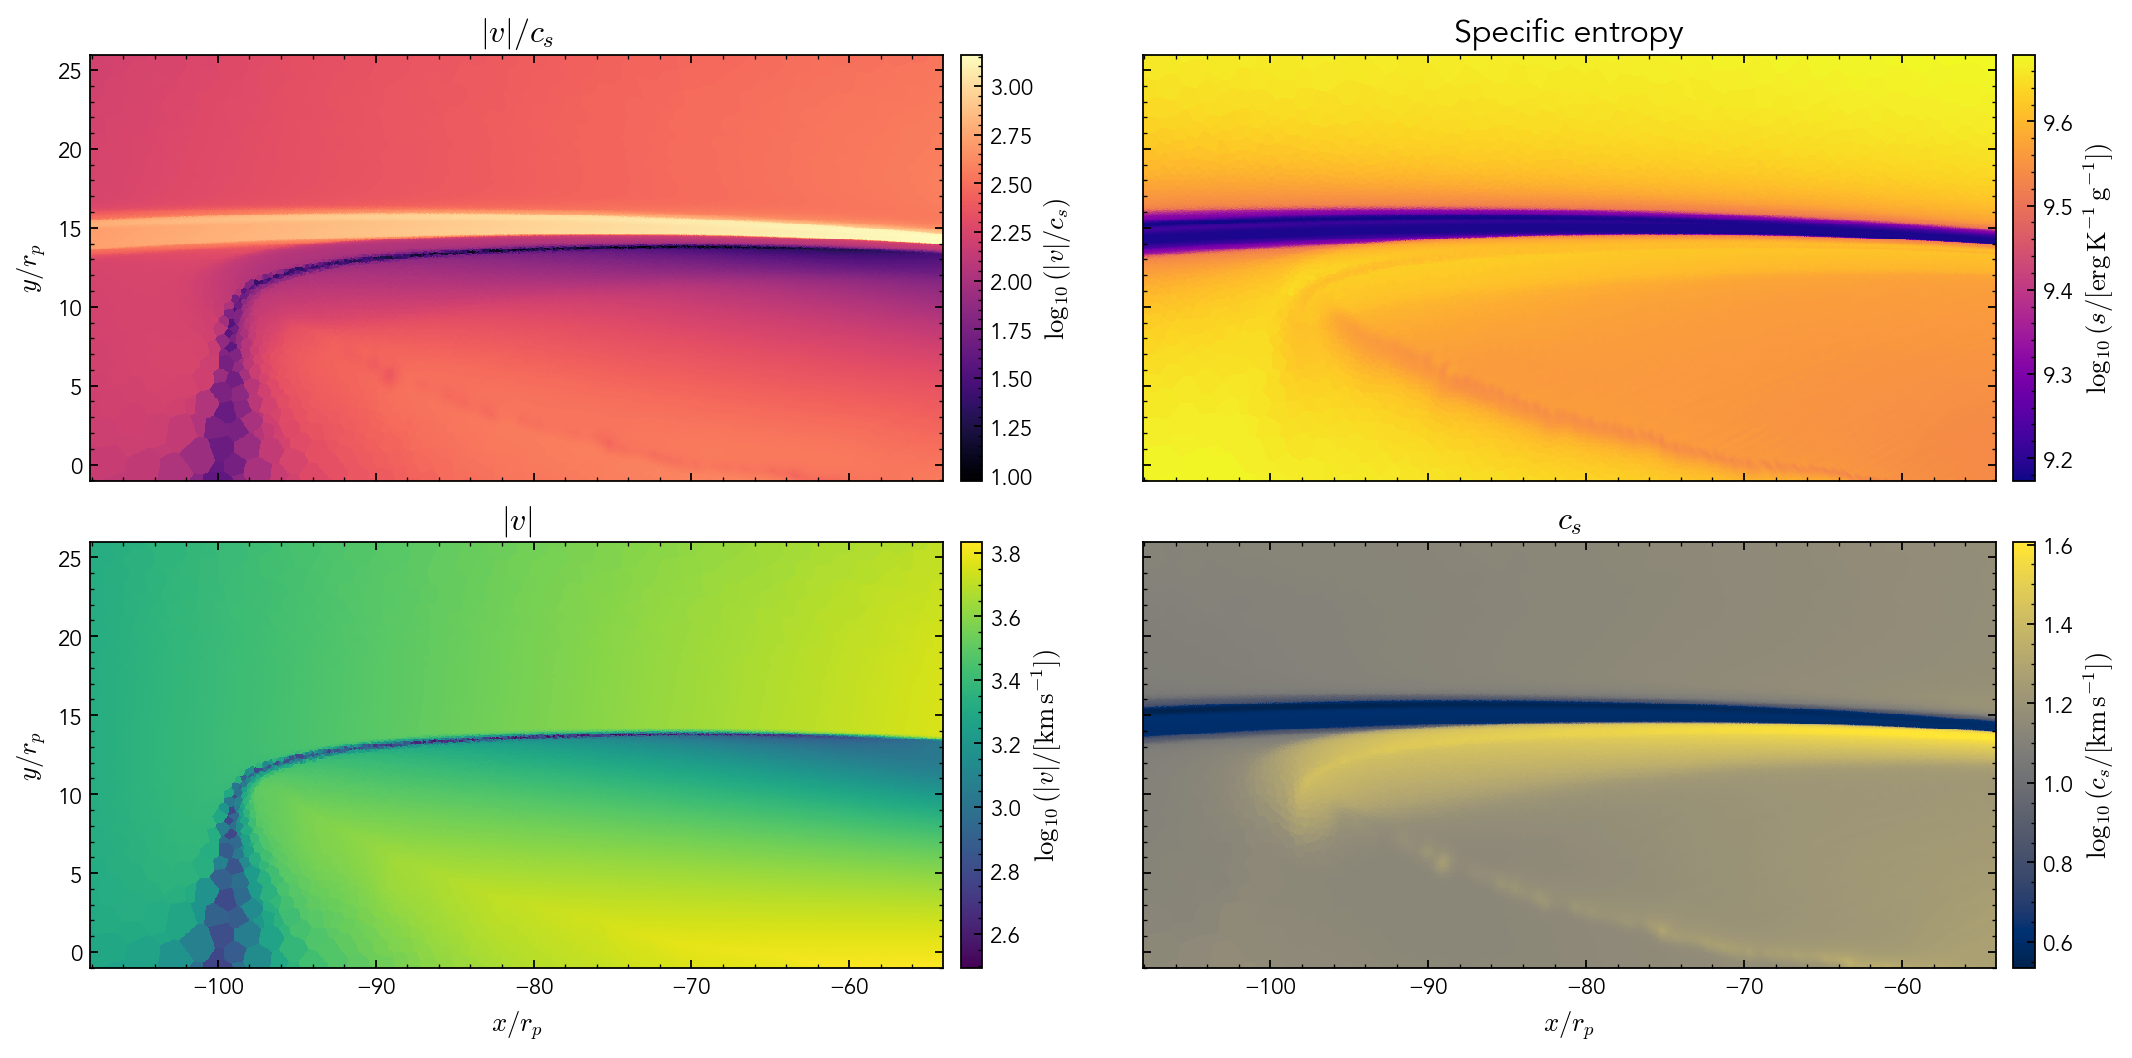

{'1e4': {'snapnum': 77,
  'time_tfb': 1.0057859673531144,
  'center_rp': (-10.583425085843034, 4.01533458408444, -0.0026021542615478465),
  'view_center_rp': (np.float64(-10.583425085843034),
   np.float64(4.01533458408444),
   np.float64(-0.0026021542615478465)),
  'half_width_rp': (7.0, 3.5, 2.0),
  'self_intersection_present': True},
 '1e5': {'snapnum': 142,
  'time_tfb': 0.5009218644053959,
  'center_rp': (-70.10152164964266,
   -3.1450587104153924,
   -0.00035850041190064064),
  'view_center_rp': (np.float64(-70.10152164964266),
   np.float64(-3.1450587104153924),
   np.float64(-0.00035850041190064064)),
  'half_width_rp': (15.0, 7.5, 3.0),
  'self_intersection_present': False},
 '1e6': {'snapnum': 850,
  'time_tfb': 1.0083246686350102,
  'center_rp': (-94.54461158864497, 12.495227152492864, -0.014973195701669205),
  'view_center_rp': (np.float64(-81.04461158864497),
   np.float64(12.495227152492864),
   np.float64(-0.014973195701669205)),
  'half_width_rp': (27.0, 13.5, 5.4),
  '

In [8]:
import gc
from IPython.display import display

VIEW_KIND = "slice"  # "slice" or "projection"
PLANE = "xy"  # "xy", "yz", or "zx"
HALF_WIDTHS_RP = {
    "1e4": (7.0, 3.5, 2.0),  # y/r_p > 0 around the selected center
    "1e5": (15.0, 7.5, 3.0),  # unchanged; pre-self-intersection
    "1e6": (27.0, 13.5, 5.4),  # 20% tighter than the previous view
}
VIEW_CENTER_OFFSETS_RP = {
    "1e4": (0.0, 0.0, 0.0),
    "1e5": (0.0, 0.0, 0.0),
    "1e6": (13.5, 0.0, 0.0),  # preserve the previous rightward shift
}
RESOLUTION = (1024, 512)
PROJECTION_DEPTH_RESOLUTION = 96
WORKERS = 8
FOUR_PANEL_FIGURE_SIZE = (13.5, 6.5)
SAVE = False
OUTPUT_ROOT = Path("/home/hey4/rich_tde/data/processed/SelfIntersectionShockZooms")

RESULTS = {}
for run, case_index in RUN_CASE_INDICES.items():
    case = load_case(run, case_index)
    half_width_rp = HALF_WIDTHS_RP[run]
    overview_figure, peaks = plot_overview(case)
    center_rp = choose_center(case, peaks)
    view_center_rp = tuple(np.asarray(center_rp) + VIEW_CENTER_OFFSETS_RP[run])
    zoom_figure, zoom_axes, zoom_fields = plot_zoom(
        case,
        view_center_rp,
        kind=VIEW_KIND,
        plane=PLANE,
        half_width_rp=half_width_rp,
        resolution=RESOLUTION,
        projection_depth_resolution=PROJECTION_DEPTH_RESOLUTION,
        workers=WORKERS,
        figure_size=FOUR_PANEL_FIGURE_SIZE,
    )
    diagnostic_figure, diagnostic_axes = plot_flow_diagnostics(
        zoom_fields,
        zoom_fields["_first_coordinate"],
        zoom_fields["_second_coordinate"],
        PLANE,
        figure_size=FOUR_PANEL_FIGURE_SIZE,
    )

    display(overview_figure)
    display(zoom_figure)
    display(diagnostic_figure)

    if SAVE:
        output_dir = OUTPUT_ROOT / run
        output_dir.mkdir(parents=True, exist_ok=True)
        basename = f"self_intersection_snap_{case['snapnum']:04d}_{VIEW_KIND}_{PLANE}"
        destinations = (
            output_dir / f"{basename}_overview.png",
            output_dir / f"{basename}_thermodynamics.png",
            output_dir / f"{basename}_flow-diagnostics.png",
        )
        for figure, destination in zip(
            (overview_figure, zoom_figure, diagnostic_figure), destinations
        ):
            figure.savefig(destination, dpi=240, bbox_inches="tight")
            print(destination)

    RESULTS[run] = {
        "snapnum": case["snapnum"],
        "time_tfb": case["time_tfb"],
        "center_rp": center_rp,
        "view_center_rp": view_center_rp,
        "half_width_rp": half_width_rp,
        "self_intersection_present": SELF_INTERSECTION_PRESENT[run],
    }
    plt.close(overview_figure)
    plt.close(zoom_figure)
    plt.close(diagnostic_figure)
    _SNAP_CACHE.pop(str(case["path"]), None)
    del zoom_fields, case
    gc.collect()

RESULTS